ricerca binaria ( dispozione in memoria)
    i valori al centro vengono visti piu frequentemente(ci passiamo piu spesso)
    valorsi fine ricerca sono piccoli, probabilemnte stessa cache line
posso disporre memoria migliore disp spaziale? 
    uso albero ricerca senza puntatorori,
        come lo costruisco: array a n order, 
se livello i, posso accedere i+4 elementi, ha 2 alla 4 elementi caricati con pre fetch

cosa visto
    possiamo veloccizare ricerca usando codico privo dibranch difficile predire
    importante tenere codniderazione itnerazioni con la memeori aquando dim superano la cache
    località memoria influenza prestazioni
    

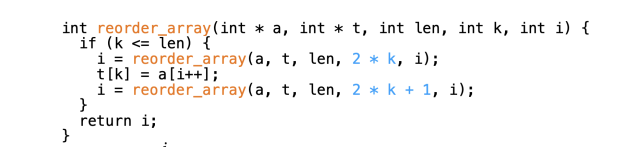

#include <stdio.h>
#include <stdlib.h>
#include <time.h>

volatile int found_tot;

int cmpfunc(const void *a, const void *b) {
    return (*(int *)a - *(int *)b);
}

int *random_vector(int len) {
    int *v = (int *)malloc(len * sizeof(int));
    for (int i = 0; i < len; i++) {
        v[i] = rand();
    }
    return v;
}

int binary_search(int *v, int len, int key) {
    int l = 0;
    int r = len;
    while (l < r) {
        int m = (l + r) / 2;
        if (v[m] >= key)
            r = m;
        else
            l = m + 1;
    }
    if (v[l] == key) {
        return l;
    } else {
        return -1;
    }
}

int binary_search_branchless(int *v, int len, int key) {
    int l = 0;
    int r = len;
    while (l < r) {
        int m = (l + r) / 2;
        int q = v[m] >= key;
        r = q * m + (1 - q) * r;
        l = q * l + (1 - q) * (m + 1);
    }
    if (v[l] == key) {
        return l;
    } else {
        return -1;
    }
}

int binary_search_branchless_prefetch(int *v, int len, int key) {
    int l = 0;
    int r = len;
    while (l < r) {
        int m = (l + r) / 2;
        int q = v[m] >= key;
        __builtin_prefetch(&v[(l + m) / 2]);
        __builtin_prefetch(&v[(m + r) / 2]);
        r = q * m + (1 - q) * r;
        l = q * l + (1 - q) * (m + 1);
    }
    if (v[l] == key) {
        return l;
    } else {
        return -1;
    }
}

float test_search(int (*f)(int *, int, int), int size, int search_size) {
    int *v = random_vector(size);
    qsort(v, size, sizeof(int), cmpfunc);
    int *keys = random_vector(search_size);
    int *pos = (int *)malloc(search_size * sizeof(int));
    clock_t start = clock();
    for (int i = 0; i < search_size; i++) {
        pos[i] = f(v, size, keys[i]);
    }
    clock_t end = clock();
    float ms = (float)(end - start) / (CLOCKS_PER_SEC / 1000.0);
    for (int i = 0; i < search_size; i++) {
        if (pos[i] != -1) {
            found_tot++;
        }
    }
    free(v);
    free(keys);
    free(pos);
    return ms;
}

int reorder_array(int *a, int *t, int len, int k, int i) {
    if (k <= len) {
        i = reorder_array(a, t, len, 2 * k, i);
        t[k] = a[i];
        i = i + 1;
        i = reorder_array(a, t, len, 2 * k + 1, i);
    }
    return i;
}

void test_reordering(int n) {
    int *a = (int *)malloc(n * sizeof(int));
    int *t = (int *)malloc((n + 1) * sizeof(int));
    for (int i = 0; i < n; i++) {
        a[i] = i;
    }

    reorder_array(a, t, n, 1, 0);

    for (int i = 1; i <= n; i++) {
        printf("%d ", t[i]);
    }
    printf("\n");
    free(a);
    free(t);
}

int search_reordered(int *v, int len, int key) {
    int i = 1;
    int pos = -1;
    while (i <= len) {
        if (v[i] == key) {
            pos = i;
        }
        i = 2 * i + (key > v[i]);
    }
    return pos;
}

int search_reordered_prefetch(int *v, int len, int key) {
    int i = 1;
    int pos = -1;
    while (i <= len) {
        if (v[i] == key) {
            pos = i;
        }
        __builtin_prefetch(v + i * 16);      // &v[i * 16];
        __builtin_prefetch(v + i * 16 + 15); // &v[i * 16 + 15];
        i = 2 * i + (key > v[i]);
    }
    return pos;
}

float test_search_reordered(int (*f)(int *, int, int), int size, int search_size) {
    int *v = random_vector(size);
    qsort(v, size, sizeof(int), cmpfunc);
    int *v_reorder = (int *)malloc((size + 1) * sizeof(int));
    v[0] = -1;
    reorder_array(v, v_reorder, size, 1, 0);
    free(v);
    int *keys = random_vector(search_size);
    int *pos = (int *)malloc(search_size * sizeof(int));
    clock_t start = clock();
    for (int i = 0; i < search_size; i++) {
        pos[i] = f(v_reorder, size, keys[i]);
    }
    clock_t end = clock();
    float ms = (float)(end - start) / (CLOCKS_PER_SEC / 1000.0);
    for (int i = 0; i < search_size; i++) {
        if (pos[i] != -1) {
            found_tot++;
        }
    }
    free(v_reorder);
    free(keys);
    free(pos);
    return ms;
}

int main(int argc, char *argv[]) {
    srand(time(NULL));
    int search_size = 1000;
    int exp_min = 10;
    int exp_max = 23;

    /* test_reordering(15); */
    /* return 0; */

    printf("\tw/ branches \tbranchless \tb. less prefetch \treordered \treord. prefetch \n");
    for (int i = exp_min; i <= exp_max; i++) {
        float t;
        printf("%d\t", i);
        t = test_search(binary_search, 1 << i, search_size);
        printf("%f\t", t);
        t = test_search(binary_search_branchless, 1 << i, search_size);
        printf("%f\t", t);
        t = test_search(binary_search_branchless_prefetch, 1 << i, search_size);
        printf("%f\t", t);
        t = test_search_reordered(search_reordered, 1 << i, search_size);
        printf("%f\t", t);
        t = test_search_reordered(search_reordered_prefetch, 1 << i, search_size);
        printf("%f\n", t);
    }
    return 0;
}
